# Superposition Hypothesis

**Survey Reference:** Section 6.2 - The Superposition Hypothesis

Model hidden states encode more features than they have dimensions. If there are $k$ features and $d$ dimensions with $k >> d$, models tend to reduce interference between features by representing them as nearly-orthogonal directions.

An implication of superposition is that there cannot be a one-to-one mapping between features and dimensions. In short: the existence of superposition causes polysemanticity

In [30]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from einops import rearrange, einsum

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

## 1. The Geometry of Superposition

### Why Can Networks Store More Features Than Dimensions?

The key insight comes from **high-dimensional geometry**: random vectors in high dimensions are almost always nearly orthogonal to each other.

### Johnson-Lindenstrauss Lemma

For $m$ random unit vectors in $\mathbb{R}^n$, the expected absolute dot product between any two vectors is:

$$\mathbb{E}[|v_i \cdot v_j|] \approx \sqrt{\frac{2}{\pi n}}$$

**What this means:**
- In 100 dimensions: average interference ≈ 0.08 (8%)
- In 1000 dimensions: average interference ≈ 0.025 (2.5%)
- As dimensions increase → vectors become more orthogonal

**Implication for neural networks:**
If features are sparse (rarely active together), we can represent $m >> n$ features in just $n$ dimensions with acceptable interference, whcih is the mathematical foundation of superposition.

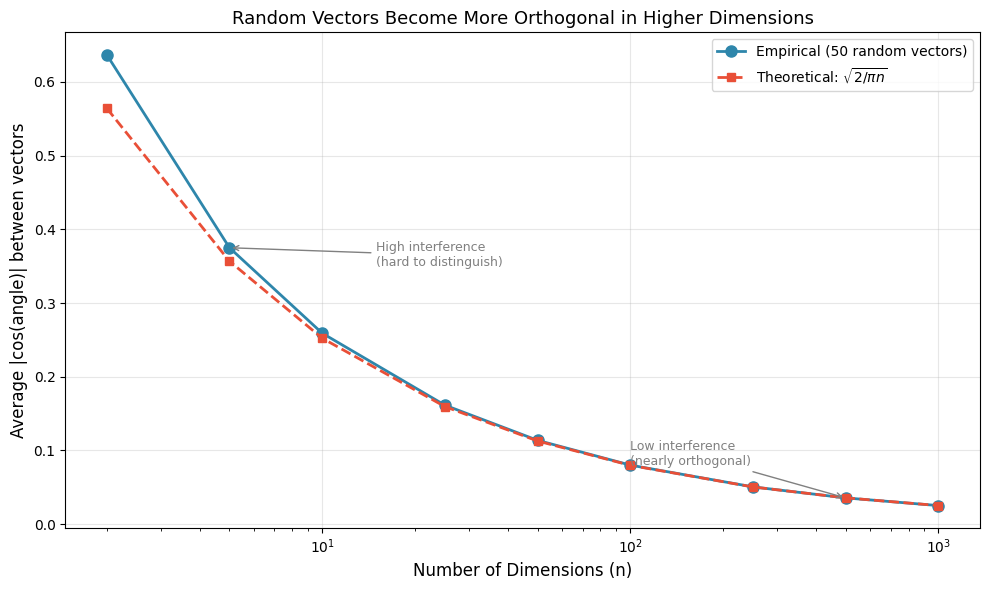


📊 Key Insight:
   In 1000 dimensions, 50 random vectors have only 2.5% average interference!
   This is why superposition works: features can share space with minimal corruption.


In [31]:
# Demonstrate near-orthogonality of random vectors in high dimensions
def measure_random_vector_angles(n_dims, n_vectors, n_trials=100):
    """Measure average dot product between random unit vectors."""
    avg_dots = []
    for _ in range(n_trials):
        vectors = torch.randn(n_vectors, n_dims)
        vectors = vectors / vectors.norm(dim=1, keepdim=True)
        dots = vectors @ vectors.T
        # Exclude diagonal
        mask = ~torch.eye(n_vectors, dtype=bool)
        avg_dots.append(dots[mask].abs().mean().item())
    return np.mean(avg_dots)

# Test across different dimensions
dimensions = [2, 5, 10, 25, 50, 100, 250, 500, 1000]
n_vectors = 50  # Try packing 50 features

# Measure empirical interference
empirical_interference = [measure_random_vector_angles(d, n_vectors) for d in dimensions]

# Theoretical prediction from Johnson-Lindenstrauss
theoretical_interference = [np.sqrt(2 / (np.pi * d)) for d in dimensions]

# Create visualization
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(dimensions, empirical_interference, 'o-', label='Empirical (50 random vectors)', 
         linewidth=2, markersize=8, color='#2E86AB')
ax.plot(dimensions, theoretical_interference, 's--', label='Theoretical: $\\sqrt{2/\\pi n}$', 
         linewidth=2, markersize=6, color='#E94F37')
ax.set_xlabel('Number of Dimensions (n)', fontsize=12)
ax.set_ylabel('Average |cos(angle)| between vectors', fontsize=12)
ax.set_title('Random Vectors Become More Orthogonal in Higher Dimensions', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

ax.annotate('High interference\n(hard to distinguish)', 
             xy=(5, empirical_interference[1]), 
             xytext=(15, 0.35),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=9, color='gray')
ax.annotate('Low interference\n(nearly orthogonal)', 
             xy=(500, empirical_interference[-2]), 
             xytext=(100, 0.08),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=9, color='gray')

plt.tight_layout()
plt.show()

print("\n📊 Key Insight:")
print(f"   In {dimensions[-1]} dimensions, {n_vectors} random vectors have only "
      f"{empirical_interference[-1]:.1%} average interference!")
print(f"   This is why superposition works: features can share space with minimal corruption.")

## 2. Toy Model of Superposition

Based on [Elhage et al. (2022)](https://transformer-circuits.pub/2022/toy_model/index.html), we train a simple autoencoder to study superposition.

### Experiment Design

**Goal:** Can a neural network represent $n$ features using only $m < n$ hidden dimensions?

We create an autoencoder that compresses high-dimensional feature vectors into a bottleneck, then reconstructs them:

```
Input x (20 features) → Hidden h (5 dims) → Output x' (20 features)
```

**Model Architecture:**
$$h = Wx \quad \text{(encode: project 20 features → 5 dimensions)}$$
$$x' = \text{ReLU}(W^T h + b) \quad \text{(decode: reconstruct 20 features)}$$

Note: We use the **same matrix $W$** for encoding and decoding (tied weights).

### Key Assumptions about Features

Real-world features have properties that enable superposition:

1. **Sparse** — Most features are inactive most of the time (e.g., "cat detector" only fires when there's a cat)
2. **Numerous** — More features exist than available dimensions ($n > m$)  
3. **Varying importance** — Some features matter more than others (importance decays as $I_i = 0.9^i$)

### Training Setup

- **Input data:** Synthetic sparse vectors where each feature is zero with probability $S$ (sparsity)
- **Loss:** Importance-weighted MSE: $L = \sum_i I_i (x_i - x'_i)^2$
- **Experiment:** Train models with different sparsity levels (0%, 70%, 90%, 99%) and compare

### Why ReLU Matters

| Model | Superposition? | Why |
|-------|---------------|-----|
| Linear: $x' = W^T W x + b$ | ❌ No | Optimal solution is PCA—no benefit from packing more features |
| ReLU: $x' = \text{ReLU}(W^T W x + b)$ | ✅ Yes | Negative bias can "clean up" interference from inactive features |

### How We Measure Superposition: The $W^T W$ Matrix

Each row $w_i$ of $W$ is the **direction in hidden space** that represents feature $i$.

The matrix $W^T W$ (size $n_{features} \times n_{features}$) reveals feature relationships:

$$(W^T W)_{ij} = w_i \cdot w_j \quad \text{(dot product between feature directions)}$$

| Entry | Formula | Meaning |
|-------|---------|---------|
| **Diagonal** | $(W^T W)_{ii} = \|w_i\|^2$ | How strongly feature $i$ is represented |
| **Off-diagonal** | $(W^T W)_{ij}$ for $i \neq j$ | **Interference** between features $i$ and $j$ |

**Interpreting the visualization:**
- **No superposition:** $W^T W$ is nearly diagonal (features are orthogonal, no interference)
- **With superposition:** $W^T W$ has off-diagonal structure (features share directions, causing interference)


### The Role of Bias

- **Positive bias:** Helps reconstruct features that are represented
- **Negative bias:** Critical for superposition! Suppresses interference noise from inactive features below zero, which ReLU then clips away

In [32]:
class ToyModel(nn.Module):
    """Toy model to study superposition."""
    
    def __init__(self, n_features, n_hidden):
        super().__init__()
        self.W = nn.Parameter(torch.randn(n_features, n_hidden) * 0.1)
        self.b = nn.Parameter(torch.zeros(n_features))
    
    def forward(self, x):
        # Encode: project to hidden space
        h = x @ self.W  # [batch, n_hidden]
        # Decode: project back with ReLU
        x_hat = torch.relu(h @ self.W.T + self.b)
        return x_hat
    
    @property
    def feature_directions(self):
        """Get the direction each feature is encoded in."""
        return self.W / self.W.norm(dim=1, keepdim=True)

In [33]:
def generate_sparse_data(n_samples, n_features, sparsity):
    """
    Generate sparse feature data.
    Each feature is active with probability (1 - sparsity).
    """
    # Feature values when active (uniform)
    values = torch.rand(n_samples, n_features)
    # Sparsity mask
    mask = torch.rand(n_samples, n_features) > sparsity
    return values * mask.float()

In [34]:
# =============================================================================
# Hyperparameters
# =============================================================================

N_FEATURES = 20          # Number of features to represent
N_HIDDEN = 5             # Bottleneck dimension (N_FEATURES > N_HIDDEN)
N_STEPS = 10000          # Training steps
BATCH_SIZE = 256         # Batch size
LR = 1e-3                # Learning rate
IMPORTANCE_DECAY = 0.9   # Feature importance decay (I_i = decay^i)
SPARSITY_LEVELS = [0.0, 0.7, 0.9, 0.99]  # Probability of feature being zero

print(f"Experiment setup:")
print(f"  Features: {N_FEATURES} → Hidden: {N_HIDDEN} (compression ratio: {N_FEATURES/N_HIDDEN}x)")
print(f"  Training: {N_STEPS} steps, batch size {BATCH_SIZE}, lr {LR}")
print(f"  Importance decay: {IMPORTANCE_DECAY} (I_i = {IMPORTANCE_DECAY}^i)")
print(f"  Sparsity levels to test: {SPARSITY_LEVELS}")

Experiment setup:
  Features: 20 → Hidden: 5 (compression ratio: 4.0x)
  Training: 10000 steps, batch size 256, lr 0.001
  Importance decay: 0.9 (I_i = 0.9^i)
  Sparsity levels to test: [0.0, 0.7, 0.9, 0.99]


In [35]:
def train_toy_model(n_features, n_hidden, sparsity, n_steps, batch_size, lr, 
                    importance_decay, use_relu=True):
    """
    Train toy model following Elhage et al. (2022).
    
    Args:
        n_features: Number of input features
        n_hidden: Number of hidden dimensions (bottleneck)
        sparsity: Probability that each feature is zero
        n_steps: Training steps
        batch_size: Batch size for training
        lr: Learning rate
        importance_decay: Exponential decay for feature importance (I_i = decay^i)
        use_relu: If True, use ReLU output; if False, linear model
    """
    # Feature importance: exponentially decaying
    importance = torch.tensor([importance_decay ** i for i in range(n_features)]).to(device)
    
    # Initialize model
    model = ToyModel(n_features, n_hidden).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    losses = []
    for step in range(n_steps):
        # Generate sparse batch
        x = generate_sparse_data(batch_size, n_features, sparsity).to(device)
        
        # Forward pass
        h = x @ model.W
        if use_relu:
            x_hat = torch.relu(h @ model.W.T + model.b)
        else:
            x_hat = h @ model.W.T + model.b
        
        # Importance-weighted MSE loss
        loss = (importance * (x - x_hat) ** 2).mean()
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        
        if step % 2000 == 0:
            print(f"Step {step:5d} | Loss: {loss.item():.4f}")
    
    return model, losses

In [36]:
# =============================================================================
# Experiment: Train models with different sparsity levels
# =============================================================================

# Train ReLU models at each sparsity level
models = {}
for sparsity in SPARSITY_LEVELS:
    print(f"\n{'='*50}")
    print(f"Training ReLU model with sparsity = {sparsity}")
    print('='*50)
    model, losses = train_toy_model(
        n_features=N_FEATURES,
        n_hidden=N_HIDDEN,
        sparsity=sparsity,
        n_steps=N_STEPS,
        batch_size=BATCH_SIZE,
        lr=LR,
        importance_decay=IMPORTANCE_DECAY,
        use_relu=True
    )
    models[sparsity] = model

# Also train a linear model for comparison
print(f"\n{'='*50}")
print("Training LINEAR model (no ReLU)")
print('='*50)
linear_model, _ = train_toy_model(
    n_features=N_FEATURES,
    n_hidden=N_HIDDEN,
    sparsity=0.9,  # Sparsity doesn't matter for linear
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    lr=LR,
    importance_decay=IMPORTANCE_DECAY,
    use_relu=False
)
models['linear'] = linear_model

print("All models trained")


Training ReLU model with sparsity = 0.0
Step     0 | Loss: 0.1267
Step  2000 | Loss: 0.0211
Step  2000 | Loss: 0.0211
Step  4000 | Loss: 0.0202
Step  4000 | Loss: 0.0202
Step  6000 | Loss: 0.0201
Step  6000 | Loss: 0.0201
Step  8000 | Loss: 0.0196
Step  8000 | Loss: 0.0196

Training ReLU model with sparsity = 0.7
Step     0 | Loss: 0.0405

Training ReLU model with sparsity = 0.7
Step     0 | Loss: 0.0405
Step  2000 | Loss: 0.0149
Step  2000 | Loss: 0.0149
Step  4000 | Loss: 0.0135
Step  4000 | Loss: 0.0135
Step  6000 | Loss: 0.0135
Step  6000 | Loss: 0.0135
Step  8000 | Loss: 0.0132
Step  8000 | Loss: 0.0132

Training ReLU model with sparsity = 0.9
Step     0 | Loss: 0.0120

Training ReLU model with sparsity = 0.9
Step     0 | Loss: 0.0120
Step  2000 | Loss: 0.0041
Step  2000 | Loss: 0.0041
Step  4000 | Loss: 0.0035
Step  4000 | Loss: 0.0035
Step  6000 | Loss: 0.0040
Step  6000 | Loss: 0.0040
Step  8000 | Loss: 0.0038
Step  8000 | Loss: 0.0038

Training ReLU model with sparsity = 0.99

### Results Interpretation

We visualize two key quantities for each trained model:

**1. The $W^T W$ Matrix (left plots)**
- Size: $n_{features} \times n_{features}$ (20 × 20)
- **Diagonal entries** $(W^T W)_{ii} = \|w_i\|^2$: How strongly each feature is represented
  - Red/dark = strongly represented ($\|w_i\|^2 \approx 1$)
  - White/light = not represented ($\|w_i\|^2 \approx 0$)
- **Off-diagonal entries** $(W^T W)_{ij}$: Interference between features $i$ and $j$
  - Blue = negative interference, Red = positive interference
  - More off-diagonal color = more superposition

**2. The Bias Vector $b$ (right plots)**
- Green bars = positive bias (helps feature reconstruction)
- Red bars = negative bias (suppresses interference noise)

**What to look for:**
- **Linear model**: Only ~5 features represented (diagonal), no superposition
- **Low sparsity (0.0)**: Similar to linear — can't afford interference
- **High sparsity (0.9, 0.99)**: Many more features represented, rich off-diagonal structure = superposition.

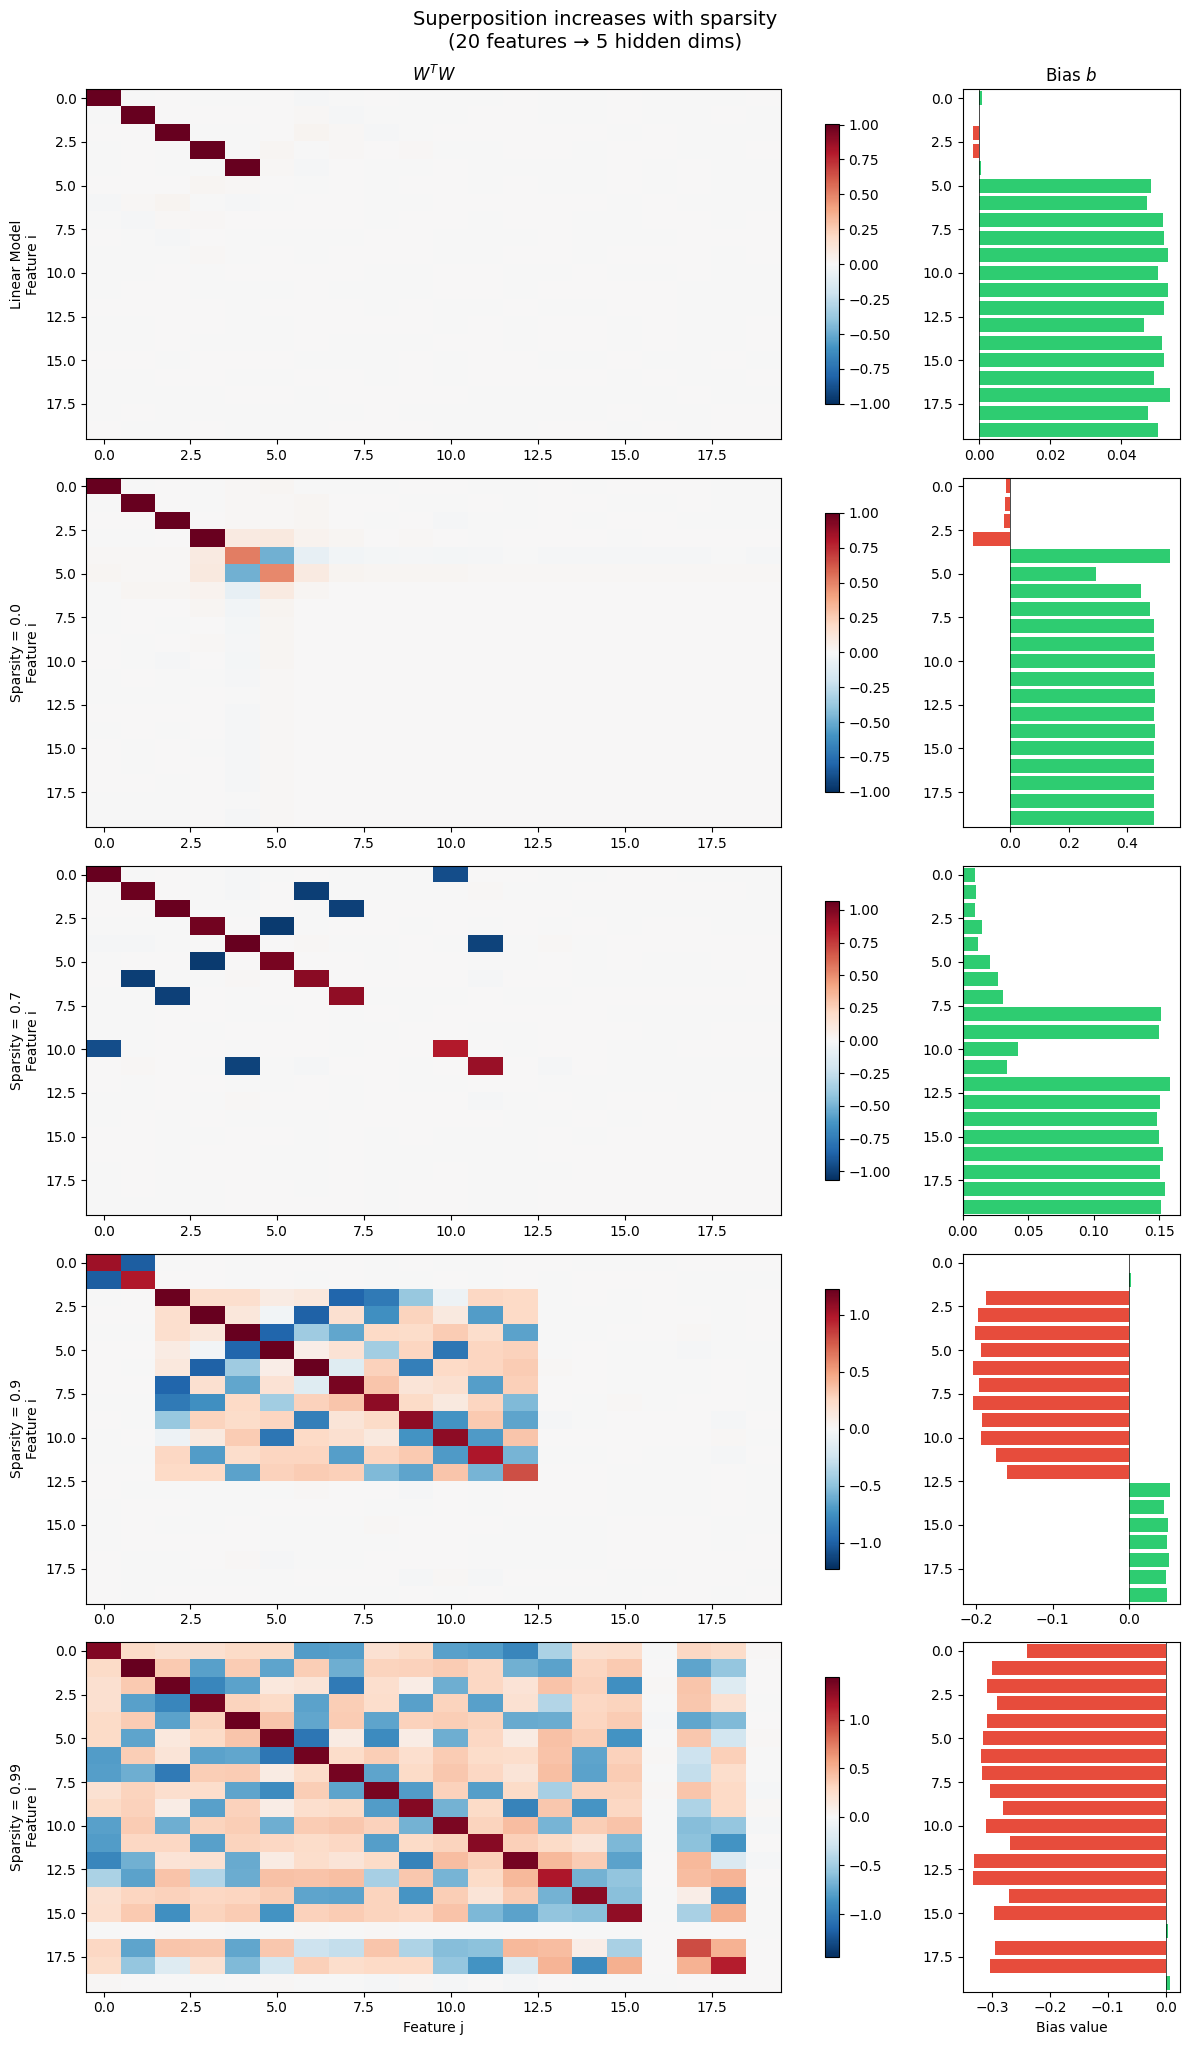


Observations:
────────────────────────────────────────────────────────────
Counting features with ||w_i||² > 0.1 (threshold for 'represented')
A feature is considered represented if its weight vector has squared norm > 0.1, meaning it has a meaningful direction in hidden space.

Linear Model        :  5 / 20 features represented
Sparsity = 0.0      :  6 / 20 features represented
Sparsity = 0.7      : 10 / 20 features represented
Sparsity = 0.9      : 13 / 20 features represented
Sparsity = 0.99     : 18 / 20 features represented


In [37]:
# =============================================================================
# Visualize Results: W^T W and bias for each sparsity level
# =============================================================================

titles = ['Linear Model', 'Sparsity = 0.0', 'Sparsity = 0.7', 'Sparsity = 0.9', 'Sparsity = 0.99']
model_keys = ['linear', 0.0, 0.7, 0.9, 0.99]

fig, axes = plt.subplots(len(model_keys), 2, figsize=(12, 4 * len(model_keys)),
                          gridspec_kw={'width_ratios': [4, 1]})

for idx, (key, title) in enumerate(zip(model_keys, titles)):
    model = models[key]
    W = model.W.detach().cpu()
    b = model.b.detach().cpu().numpy()
    WtW = (W @ W.T).numpy()
    
    ax_wtw = axes[idx, 0]
    ax_b = axes[idx, 1]
    
    # Plot W^T W
    vmax = max(1.0, abs(WtW).max())
    im = ax_wtw.imshow(WtW, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    ax_wtw.set_ylabel(f'{title}\nFeature i')
    if idx == len(model_keys) - 1:
        ax_wtw.set_xlabel('Feature j')
    ax_wtw.set_title('$W^T W$' if idx == 0 else '')
    plt.colorbar(im, ax=ax_wtw, shrink=0.8)
    
    # Plot bias
    colors = ['#2ecc71' if x >= 0 else '#e74c3c' for x in b]
    ax_b.barh(range(len(b)), b, color=colors)
    ax_b.set_ylim(len(b) - 0.5, -0.5)
    ax_b.axvline(x=0, color='black', linewidth=0.5)
    ax_b.set_title('Bias $b$' if idx == 0 else '')
    if idx == len(model_keys) - 1:
        ax_b.set_xlabel('Bias value')

plt.tight_layout()
plt.suptitle('Superposition increases with sparsity\n(20 features → 5 hidden dims)', 
             fontsize=14, y=1.02)
plt.show()

# Print summary
print("\nObservations:")
print("─" * 60)
print("Counting features with ||w_i||² > 0.1 (threshold for 'represented')")
print("A feature is considered represented if its weight vector has squared norm > 0.1, meaning it has a meaningful direction in hidden space.\n")

for key, title in zip(model_keys, titles):
    W = models[key].W.detach().cpu()
    norms = (W ** 2).sum(dim=1)
    n_represented = (norms > 0.1).sum().item()
    print(f"{title:20s}: {n_represented:2d} / {N_FEATURES} features represented")

### Conclusion:

1. Superposition explains why neurons are polysemantic. They respond to multiple unrelated features
2. SAEs attempt to decompose superposed representations into individual features
3. Linear probes work as features are approximately linear directions

→ **03_privileged_access_hypothesis.ipynb**: When do neurons align with interpretable features?